<a href="https://colab.research.google.com/github/ElFL4/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

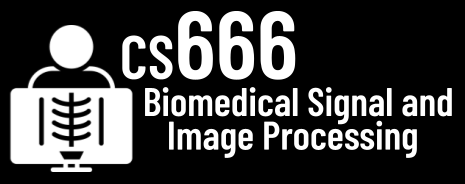
#Assignment 4

In [75]:
# NAME: Elley Lavelle

In [76]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [77]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['f', 'clf']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [78]:
# we are using mahotas again, so lets install it!
!pip install mahotas

In [79]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [80]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!
!wget -O xray.zip https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1

--2026-04-22 03:26:49--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucccbf15a2aab3eb22ff4fd26b37.dl.dropboxusercontent.com/cd/0/inline/C_BLBBTRojAy92UzAIfA7V--YRCxegTReIjQfKd7n3yygYcV7e-BfmclXdgvbxj20ib_K7SHhzHbWWuBF5AgCq1tMyHnzsit5DkLdfIZPads1V7zFGA6NN9_FoV7BaUyZOI/file# [following]
--2026-04-22 03:26:49--  https://ucccbf15a2aab3eb22ff4fd26b37.dl.dropboxusercontent.com/cd/0/inline/C_BLBBTRojAy92UzAIfA7V--YRCxegTReIjQfKd7n3yygYcV7e-BfmclXdgvbxj20ib_K7SHhzHbWWuBF5AgCq1tMyHnzsit5DkLdfIZPads1V7zFGA6NN9_FoV7BaUyZOI/file
Resolving ucccbf15a2aab3eb22ff4fd26b37.dl.dropboxusercontent.com (ucccbf15a2aab3eb22ff4fd26b37.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connecting to ucccbf15a2a

In [81]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [82]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [83]:
# TODO: Please display this image and print the dimensions!

In [84]:
# TODO: YOUR CODE

img Dimensions: (1858, 2090)


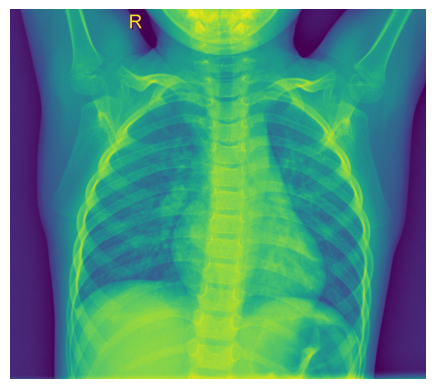

In [85]:
# Image display
plt.imshow(img)
plt.axis('off')

# Dismensions print
print("img Dimensions:", img.shape)

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [86]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [87]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.

# TODO: Operation 1) YOUR ANSWER
# It is allocating space for the files from NORMAL_DIR, PNEUMONIA_DIR, and
# COVID_DIR, allowing for 300x300 images.

# TODO: Operation 2) YOUR ANSWER
# It is taking the images, grayscaling them if they aren't and resizing them to
# 300x300 pixels.

# TODO: Operation 3) YOUR ANSWER
# It is putting a loaded image (one that is changed by the previous two code
# blocks) into a dataset.

In [88]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

In [89]:
# TODO: YOUR CODE (I just thought both versions would be neat.)

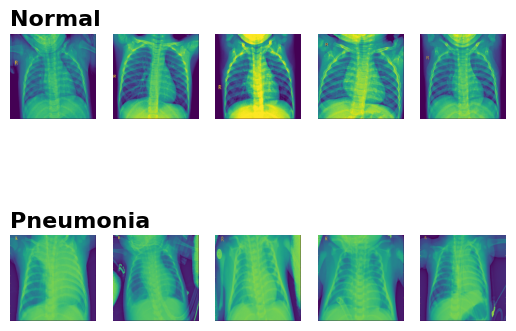

In [90]:
def plot_img(data, titles, num_img=5):
    fig, axes = plt.subplots(len(data), num_img)

    for i, images in enumerate(data):
        for j in range(num_img):
            if len(data) > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]
            ax.imshow(images[j])
            ax.axis('off')
            if j == 0:
                ax.set_title(titles[i], loc='left', fontweight='bold', fontsize=16)

    plt.show()

plot_img(data[:2], ["Normal", "Pneumonia"], num_img=5)

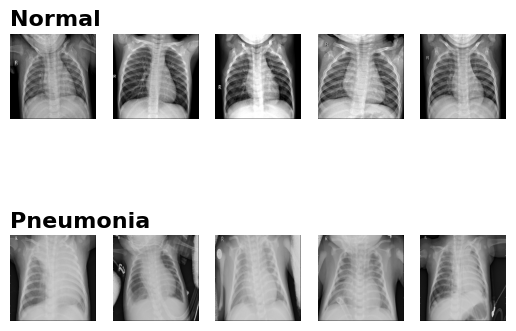

In [91]:
def plot_img_GRAY(data, titles, num_img=5):
    fig, axes = plt.subplots(len(data), num_img)

    for i, images in enumerate(data):
        for j in range(num_img):
            if len(data) > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]
            ax.imshow(images[j], cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(titles[i], loc='left', fontweight='bold', fontsize=16)

    plt.show()

plot_img_GRAY(data[:2], ["Normal", "Pneumonia"], num_img=5)

**Task 3:** Setup training and testing data. [15 Points]

In [92]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [93]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [94]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.zeros((TRAINING_COUNT * 3), dtype=np.float32) # TODO

for i in range(3):
  y_train[i * TRAINING_COUNT : (i + 1) * TRAINING_COUNT] = i

In [95]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [96]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.zeros( (TESTING_COUNT * 3), dtype=np.float32) # TODO

for i in range(3):
  y_test[i * TRAINING_COUNT : (i + 1) * TRAINING_COUNT] = i

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [97]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [98]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [99]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [100]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [116]:
# TODO: YOUR ANSWER
# Random Forest is a machine learning algorithm. It builds multiple decision
# trees and compares/combines their predictions to (hopefully) increase
# accuracy. Random Forest is also good to use when you want to control or avoid
# over-fitting. A Random Forest would not be a Random FOREST without multiple
# decision TREES. (Unless that tree was Pando, though that isn't quite right
# or truly related.)

In [102]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.5

In [103]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [104]:
# TODO: YOUR ANSWER
# It's not amazing, but it could definitely be worse. clf.score returns the mean
# accuracy of the data it's given. So, at least it's not zero... Though,
# 0.48333333333333334 is still not great.

# I did rerun the code and got a higher score, 0.5. Which, although better
# than 0.48333333333333334, is still not amazing.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [105]:
# How many trees are used in Task 4?

In [106]:
# TODO: YOUR ANSWER
# Task 4 used 100 trees (the default number of trees).

In [107]:
# Now, please use a single tree and observe the testing performance.

In [117]:
# TODO: YOUR CODE
clf = RandomForestClassifier(n_estimators=1)

clf.fit( X_train, y_train )

clf.score(X_test, y_test)

0.4583333333333333

In [109]:
# Are you surprised?

In [110]:
# TODO: YOUR ANSWER
# Slightly, because I thought the accuracy score would be much lower.
# A single tree doesn't (usually) make a forest alone.

**Bonus:** Let's take a closer look! [33 Points]

In [111]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [112]:
# TODO: YOUR CODE AND YOUR ANSWER

In [113]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

In [114]:
# TODO: YOUR CODE AND YOUR ANSWER

In [115]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw